# Green & Fast Delivery — Machine Learning MVP

<br>

<p align="center">
  <img src="https://cdn-icons-png.flaticon.com/512/2972/2972185.png" width="120">
</p>

<br>


## Cadre académique

- **Module** : Machine Learning supervisé avec Python
- **Programme** : NEXA School IA — Master 1

<br>

## Équipe projet

- BAITE Camille
- CASTERAS Maxime
- DELGADO David
-
## Contexte

Ce projet s’inscrit dans le cadre du module de **Machine Learning supervisé avec Python**.

Il répond à un besoin métier formulé par Eco-Delivery :
optimiser la gestion des livraisons afin de réduire les délais et l’empreinte carbone.

L’objectif est de construire rapidement un **MVP fonctionnel** capable de fournir une première estimation prédictive à partir des données disponibles.

<br>



## Objectifs

- Mettre en place un pipeline de données complet (chargement, nettoyage, transformation)
- Gérer les valeurs manquantes et la qualité des données
- Identifier une variable cible pertinente
- Construire un modèle baseline simple
- Évaluer les performances du modèle
- Fournir une solution reproductible et exploitable

<br>

## Approche (XP / Agile)

Le projet suit une logique **Extreme Programming (XP)** :

- Livraison rapide d’un prototype fonctionnel
- Simplicité des solutions (baseline avant optimisation)
- Code lisible et modulaire
- Amélioration itérative

L’objectif n’est pas d’obtenir le meilleur modèle, mais de **livrer de la valeur rapidement**.

<br>

## Données

Dataset utilisé :
https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset

Les données contiennent :
- Informations sur les commandes
- Données temporelles
- Informations sur les livraisons

<br>



## Pipeline

Le pipeline mis en place comprend :

1. Chargement des données
2. Nettoyage :
   - gestion des valeurs manquantes
3. Transformation :
   - variables numériques → normalisation
   - variables catégorielles → encodage
4. Modélisation :
   - modèle baseline (SGDClassifier)
5. Évaluation :
   - accuracy
   - classification report

<br>

## Modèle

Le modèle utilisé est :

- **SGDClassifier**

Choix volontaire :
- rapide
- simple
- adapté à une première itération

Ce modèle sert de **baseline** pour valider le pipeline.

<br>


<br>
<br>
<br>

## **1. Introduction du projet**

Ce projet vise à construire un modèle de Machine Learning permettant d’analyser et de prédire des comportements liés aux livraisons de repas à partir de données opérationnelles.

L’objectif est double :
- comprendre les facteurs influençant la performance des livraisons (temps, efficacité, répartition)
- développer un modèle baseline capable de produire une première prédiction exploitable

Le projet s’inscrit dans une logique MVP, avec une approche Agile (XP), privilégiant la livraison rapide d’un pipeline fonctionnel avant toute optimisation avancée.

In [958]:
import os
import pandas as pd
import numpy as np

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score

import kagglehub

In [959]:
def load_data(train_path: str, test_path: str) -> tuple:
    """
    Charge les datasets d'entraînement et de test depuis les fichiers.

    Paramètres
    ----------
    train_path : str
        Chemin vers le fichier train.csv
    test_path : str
        Chemin vers le fichier test.csv

    Retour
    -------
    df_train : pd.DataFrame
        Dataset d'entraînement
    df_test : pd.DataFrame
        Dataset de test
    """
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    return df_train, df_test

In [960]:
df_train, df_test = load_data("../data/train.csv", "../data/test.csv")

In [961]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [962]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          11399 non-null  object 
 3   Delivery_person_Ratings      11399 non-null  object 
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  11399 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weatherconditions            11399 non-null  object 
 12  Road_traffic_density         11399 non-null  object 
 13  Vehicle_conditio

In [963]:
def add_split_flag(df_train: pd.DataFrame, df_test: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute un indicateur permettant de distinguer les données train et test,
    puis concatène les deux datasets.

    Objectif
    --------
    - Permettre un preprocessing global (nettoyage, encoding, etc.)
    - Éviter toute confusion entre train et test après concaténation

    Retour
    -------
    df_all : pd.DataFrame
        Dataset combiné avec indicateur is_train
    """
    df_train = df_train.copy()
    df_test = df_test.copy()

    # Indicateur d'origine des données (1 = train, 0 = test)
    df_train["is_train"] = 1
    df_test["is_train"] = 0

    # Ajouter la target au test si absente (nécessaire pour concat)
    if "Time_taken(min)" not in df_test.columns:
        df_test["Time_taken(min)"] = None

    # Concaténation pour traitement unifié
    df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

    return df_all

In [964]:
df_all_info = add_split_flag(df_train, df_test)

df = df_train


In [965]:
def get_distribution(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Calcule le nombre et le pourcentage de chaque valeur d'une colonne.

    Paramètres
    ----------
    df : pd.DataFrame
    column : str
        Colonne à analyser

    Retour
    -------
    pd.DataFrame
        Tableau avec count et percentage
    """
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    return result


In [966]:
# Utilisation
dist = get_distribution(df_all_info, "is_train")
print(dist)

          count  percentage
is_train                   
1         45593        80.0
0         11399        20.0


In [967]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def analyze_missing_by_type(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyse avancée des valeurs manquantes par type de variable.
    """
    result = []

    total = len(df)

    for col in df.columns:
        missing = df[col].isna().sum()
        pct = (missing / total) * 100

        dtype = df[col].dtype

        if pd.api.types.is_numeric_dtype(df[col]):
            col_type = "numerical"
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            col_type = "datetime"
        else:
            col_type = "categorical"

        result.append({
            "column": col,
            "type": col_type,
            "dtype": dtype,
            "missing_count": missing,
            "missing_pct": round(pct, 2)
        })

    return pd.DataFrame(result).sort_values(by="missing_pct", ascending=False)



def clean_strings(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:

    """
    Nettoie les colonnes texte + affiche impact avant/après.

    Actions
    -------
    - trim espaces
    - remplacement "NaN", "" → pd.NA

    Paramètre
    ---------
    verbose : bool
        Affiche les stats avant/après
    """

    df = df.copy()

    if verbose:
        print("=== AVANT CLEAN ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    # seulement sur colonnes object
    obj_cols = df.select_dtypes(include="object").columns

    for col in obj_cols:
        df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

    df = df.replace(["NaN", "nan", ""], pd.NA)

    if verbose:
        print("\n=== APRÈS CLEAN ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    return df


def impute_missing_values(
    df: pd.DataFrame,
    strategy_config: dict = None,
    default_num: str = "median",
    default_cat: str = "mode",
    default_datetime: str = "median",
    verbose: bool = True
) -> pd.DataFrame:

    df = df.copy()

    if verbose:
        print("=== AVANT IMPUTATION ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    for col in df.columns:
        if df[col].isna().sum() == 0:
            continue

        # FIX CRITIQUE ML : ne jamais imputer la target
        if col == "Time_taken(min)":
            continue

        strategy = None
        if strategy_config and col in strategy_config:
            strategy = strategy_config[col]

        if strategy is None:
            if pd.api.types.is_numeric_dtype(df[col]):
                strategy = default_num
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                strategy = default_datetime
            else:
                strategy = default_cat

        if strategy == "drop":
            df = df[df[col].notna()]

        elif strategy == "mean":
            df[col] = df[col].fillna(df[col].mean())

        elif strategy == "median":
            df[col] = df[col].fillna(df[col].median())

        elif strategy == "mode":
            df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

        elif strategy.startswith("constant:"):
            value = strategy.split(":")[1]
            df[col] = df[col].fillna(value)

    if verbose:
        print("\n=== APRÈS IMPUTATION ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    return df


def convert_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convertit les colonnes vers les bons types.

    Objectif
    --------
    - Transformer les colonnes numériques stockées en texte
    - Nettoyer la variable cible
    """
    df = df.copy()

    # Variables numériques (actuellement en string)
    df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")
    df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
    df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")

    # Target : "30 (min)" → 30
    if "Time_taken(min)" in df.columns:
        df["Time_taken(min)"] = df["Time_taken(min)"].astype(str).str.extract(r"(\d+)").astype(float)

    return df


# =========================================================
# VISUALISATION
# =========================================================

def plot_missing(df: pd.DataFrame, title: str = "") -> None:
    summary = analyze_missing_by_type(df)
    summary = summary[summary["missing_count"] > 0]

    if summary.empty:
        print(f"{title} : aucune valeur manquante")
        return

    plot_df = summary.copy()
    plot_df["non_missing_pct"] = 100 - plot_df["missing_pct"]
    plot_df = plot_df.sort_values(by="missing_pct", ascending=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_df["column"],
        plot_df["missing_pct"],
        label="Missing",
        color="red"
    )

    plt.barh(
        plot_df["column"],
        plot_df["non_missing_pct"],
        left=plot_df["missing_pct"],
        label="Non-missing",
        color="green"
    )

    plt.xlabel("Percentage")
    plt.title(title)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [968]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [969]:
# =========================
# TARGET
# =========================
target_col = "Time_taken(min)"

# =========================
# CONFIG IMPUTATION
# =========================
strategy_config = {
    "Delivery_person_Age": "median",
    "Delivery_person_Ratings": "median",
    "multiple_deliveries": "median",

    "Festival": "constant:No",
    "City": "mode",
    "Road_traffic_density": "mode",

    "order_hour": "median",
    "pickup_hour": "median",

    "Order_Year": "median",
    "Order_Month": "median",
    "Order_Day": "median",
    "Order_weekday": "median"
}

In [970]:
def clean_target_numeric(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Nettoie une colonne cible contenant du texte type '30 (min)'
    et la convertit en numérique (float).

    Étapes :
    - extraction des nombres
    - conversion en float
    - suppression des lignes NaN

    Paramètres
    ----------
    df : DataFrame
    col : nom de la colonne cible

    Retour
    ------
    DataFrame nettoyé
    """
    df = df.copy()

    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

    df = df[df[col].notna()]

    return df

In [971]:
def preprocess_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # =========================
    # CLEAN
    # =========================
    df = clean_strings(df)

    # =========================
    # CONVERT TYPES
    # =========================
    df = convert_types(df)

    # =========================
    # DATE
    # =========================
    df["Order_Date"] = df["Order_Date"].astype(str).str.strip()
    df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce")

    df["Order_Year"] = df["Order_Date"].dt.year
    df["Order_Month"] = df["Order_Date"].dt.month
    df["Order_Day"] = df["Order_Date"].dt.day
    df["Order_weekday"] = df["Order_Date"].dt.weekday

    df["is_order_date_missing"] = df["Order_Date"].isna().astype(int)

    # =========================
    # TIME CLEAN
    # =========================
    df["Time_Orderd"] = df["Time_Orderd"].astype(str).str.strip()
    df["Time_Order_picked"] = df["Time_Order_picked"].astype(str).str.strip()

    df["Time_Orderd"] = df["Time_Orderd"].str.extract(r"(\d{1,2}:\d{1,2})")
    df["Time_Order_picked"] = df["Time_Order_picked"].str.extract(r"(\d{1,2}:\d{1,2})")

    df["Time_Orderd"] = df["Time_Orderd"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Order_picked"] = df["Time_Order_picked"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M", errors="coerce")
    df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M", errors="coerce")

    # =========================
    # TIME FEATURES
    # =========================
    df["order_hour"] = df["Time_Orderd"].dt.hour
    df["pickup_hour"] = df["Time_Order_picked"].dt.hour

    df["is_order_time_missing"] = df["Time_Orderd"].isna().astype(int)
    df["is_pickup_time_missing"] = df["Time_Order_picked"].isna().astype(int)

    # =========================
    # DROP RAW
    # =========================
    df = df.drop(columns=["Time_Orderd", "Time_Order_picked", "Order_Date"])

    return df

In [972]:
def preprocess_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # =========================
    # CLEAN
    # =========================
    df = clean_strings(df)

    # =========================
    # CONVERT TYPES
    # =========================
    df = convert_types(df)

    # =========================
    # GEO FEATURES (IMPORTANT)
    # =========================
    import numpy as np

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))

        return R * c

    df["distance_km"] = haversine(
        df["Restaurant_latitude"],
        df["Restaurant_longitude"],
        df["Delivery_location_latitude"],
        df["Delivery_location_longitude"]
    )

    df = df.drop(columns=[
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ])

    # =========================
    # DATE
    # =========================
    df["Order_Date"] = df["Order_Date"].astype(str).str.strip()
    df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce")

    df["Order_Year"] = df["Order_Date"].dt.year
    df["Order_Month"] = df["Order_Date"].dt.month
    df["Order_Day"] = df["Order_Date"].dt.day
    df["Order_weekday"] = df["Order_Date"].dt.weekday

    df["is_order_date_missing"] = df["Order_Date"].isna().astype(int)

    # =========================
    # TIME CLEAN
    # =========================
    df["Time_Orderd"] = df["Time_Orderd"].astype(str).str.strip()
    df["Time_Order_picked"] = df["Time_Order_picked"].astype(str).str.strip()

    df["Time_Orderd"] = df["Time_Orderd"].str.extract(r"(\d{1,2}:\d{1,2})")
    df["Time_Order_picked"] = df["Time_Order_picked"].str.extract(r"(\d{1,2}:\d{1,2})")

    df["Time_Orderd"] = df["Time_Orderd"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Order_picked"] = df["Time_Order_picked"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M", errors="coerce")
    df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M", errors="coerce")

    # =========================
    # TIME FEATURES
    # =========================
    df["order_hour"] = df["Time_Orderd"].dt.hour
    df["pickup_hour"] = df["Time_Order_picked"].dt.hour

    df["is_order_time_missing"] = df["Time_Orderd"].isna().astype(int)
    df["is_pickup_time_missing"] = df["Time_Order_picked"].isna().astype(int)

    # =========================
    # PEAK HOUR FEATURE (AJOUT)
    # =========================
    df["is_peak_hour"] = df["order_hour"].apply(
        lambda x: 1 if (pd.notna(x) and ((12 <= x <= 14) or (19 <= x <= 21))) else 0
    )

    # =========================
    # DROP RAW
    # =========================
    df = df.drop(columns=["Time_Orderd", "Time_Order_picked", "Order_Date"])

    return df

## Prétraitement des données

Cette étape vise à transformer les données brutes en variables exploitables pour la modélisation, en combinant nettoyage, transformation et création de nouvelles features.

---

### 1. Nettoyage et préparation initiale

Les données sont d’abord nettoyées afin de garantir leur cohérence :

- Suppression des espaces inutiles dans les variables textuelles
- Standardisation des formats
- Conversion des types de variables (numériques, dates, catégorielles)

Cette étape permet d’éviter les erreurs lors des transformations suivantes.

---

### 2. Feature engineering

#### Variables géographiques

Une nouvelle variable **distance_km** est créée à partir des coordonnées GPS du restaurant et du client.

- Calcul basé sur la formule de Haversine
- Permet d’estimer la distance réelle de livraison

Les coordonnées géographiques brutes sont ensuite supprimées pour éviter la redondance et réduire la dimension des données.

---

#### Variables temporelles (date)

La variable de date est transformée pour extraire plusieurs informations :

- Année de la commande
- Mois
- Jour
- Jour de la semaine

Un indicateur est également ajouté pour signaler les dates manquantes.

---

#### Variables temporelles (heure)

Les variables d’heure sont nettoyées et converties en format exploitable.

Deux nouvelles variables sont créées :

- **order_hour** : heure de la commande
- **pickup_hour** : heure de prise en charge

Des indicateurs de valeurs manquantes sont également ajoutés pour capturer l’absence d’information.

Les variables temporelles brutes sont ensuite supprimées.

---

### 3. Gestion des valeurs manquantes

Les valeurs manquantes sont traitées à l’aide d’une stratégie adaptée à chaque variable :

- Médiane pour les variables numériques
- Mode pour certaines variables catégorielles
- Valeur constante lorsque pertinent (ex : Festival = "No")

Cette approche permet de conserver un maximum d’observations tout en limitant les biais.

---

### 4. Nettoyage de la variable cible

La variable cible (*Time_taken(min)*) est convertie en format numérique :

- Suppression des caractères non numériques
- Conversion en type exploitable pour la modélisation

Les lignes avec valeurs invalides sont traitées afin de garantir la qualité du modèle.

---

Ce preprocessing permet :

- D’améliorer la qualité des données
- D’ajouter des variables pertinentes (distance, temps)
- De réduire le bruit et les incohérences

Ces transformations sont essentielles pour obtenir des performances fiables lors de la phase de modélisation.

In [973]:
# =========================
# PREPROCESS TRAIN
# =========================
df_train_processed = preprocess_features(df)

df_train_processed = impute_missing_values(
    df_train_processed,
    strategy_config=strategy_config
)

df_train_processed = clean_target_numeric(
    df_train_processed,
    target_col
)

=== AVANT CLEAN ===
Empty DataFrame
Columns: [column, type, dtype, missing_count, missing_pct]
Index: []

=== APRÈS CLEAN ===
                     column         type   dtype  missing_count  missing_pct
3   Delivery_person_Ratings  categorical  object           1908         4.18
2       Delivery_person_Age  categorical  object           1854         4.07
9               Time_Orderd  categorical  object           1731         3.80
18                     City  categorical  object           1200         2.63
16      multiple_deliveries  categorical  object            993         2.18
12     Road_traffic_density  categorical  object            601         1.32
17                 Festival  categorical  object            228         0.50
=== AVANT IMPUTATION ===
                     column         type    dtype  missing_count  missing_pct
3   Delivery_person_Ratings    numerical  float64           1908         4.18
2       Delivery_person_Age    numerical  float64           1854         4.07

In [974]:
import seaborn as sns
import matplotlib.pyplot as plt


col = df_train_processed["Time_taken(min)"]

stats_df = pd.DataFrame({
    "Statistique": [
        "count", "mean", "std", "min", "25%", "50% (median)", "75%", "max",
        "skewness", "kurtosis"
    ],
    "Valeur": [
        col.count(),
        col.mean(),
        col.std(),
        col.min(),
        col.quantile(0.25),
        col.median(),
        col.quantile(0.75),
        col.max(),
        col.skew(),
        col.kurt()
    ]
})

print(stats_df)


    Statistique        Valeur
0         count  45593.000000
1          mean     26.294607
2           std      9.383806
3           min     10.000000
4           25%     19.000000
5  50% (median)     26.000000
6           75%     32.000000
7           max     54.000000
8      skewness      0.485951
9      kurtosis     -0.310798


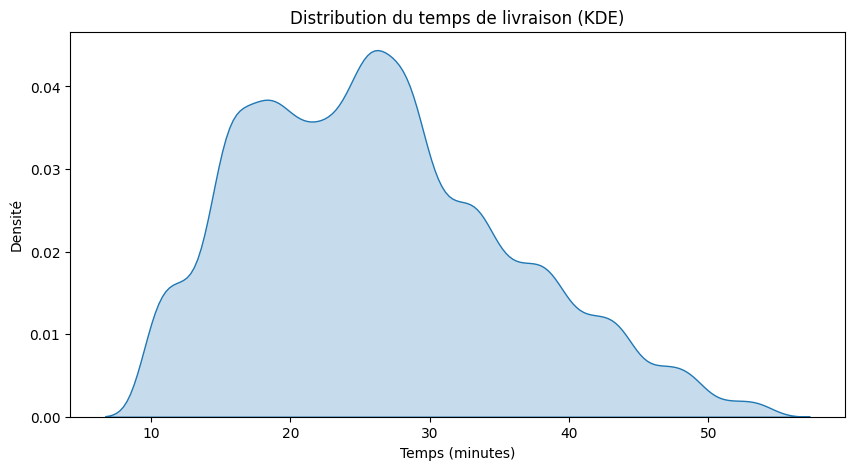

In [975]:

plt.figure(figsize=(10,5))

sns.kdeplot(
    df_train_processed["Time_taken(min)"],
    fill=True
)

plt.title("Distribution du temps de livraison (KDE)")
plt.xlabel("Temps (minutes)")
plt.ylabel("Densité")

plt.show()

In [976]:
num_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "order_hour",
    "pickup_hour",
    "Order_Year",
    "Order_Month",
    "Order_Day",
    "distance_km"]

cat_nominal_cols = [
    "City",
    "Festival",
    "Type_of_order",
    "Type_of_vehicle",
    "Weatherconditions",
    "Order_weekday",
    "multiple_deliveries",
    "is_peak_hour"
]

cat_ordinal_cols = [
    "Road_traffic_density"
]

ordinal_categories = [
    ["Low", "Medium", "High", "Jam"]
]



In [977]:
def plot_correlation_matrix(
    df,
    columns=None,
    figsize=(12, 10),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    font_size=8,
    rotate_x=45,
    rotate_y=0,
    mask_upper=False,
    only_numeric=True,
    title="Correlation Matrix"
):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # =========================
    # SELECT COLUMNS
    # =========================
    if columns is not None:
        df_plot = df[columns].copy()
    else:
        if only_numeric:
            df_plot = df.select_dtypes(include="number")
        else:
            df_plot = df.copy()

    # =========================
    # CORRELATION
    # =========================
    corr = df_plot.corr()

    # =========================
    # MASK (OPTIONAL)
    # =========================
    mask = None
    if mask_upper:
        mask = np.triu(np.ones_like(corr, dtype=bool))

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        mask=mask,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        annot_kws={"size": font_size},
        linewidths=0.5
    )

    plt.title(title, fontsize=14)
    plt.xticks(rotation=rotate_x, ha="right", fontsize=font_size)
    plt.yticks(rotation=rotate_y, fontsize=font_size)

    plt.tight_layout()
    plt.show()




<br>
<br>

<br>
<br>

## Analyse des corrélations avec la variable cible

La matrice de corrélation permet d’identifier les relations linéaires entre les variables explicatives et le temps de livraison (*Time_taken(min)*).

### Variables les plus corrélées

- **Delivery_person_Ratings** : **-0.33**
  → Corrélation négative modérée
  → Les livreurs mieux notés tendent à livrer plus rapidement
  → Variable pertinente pour le modèle

- **Delivery_person_Age** : **+0.29**
  → Corrélation positive modérée
  → Les livreurs plus âgés ont tendance à avoir des temps de livraison légèrement plus élevés

- **pickup_hour** : **+0.20**
  → Impact du moment de récupération de la commande
  → Confirme l’effet des heures de pointe

- **order_hour** : **+0.18**
  → Influence du moment de la commande
  → Cohérent avec la variation du trafic selon l’heure

---

### Relations entre variables (colinéarité)

- **order_hour ↔ pickup_hour** : **0.79**
  → Forte corrélation
  → Variables redondantes
  → Possibilité de supprimer l’une des deux pour simplifier le modèle

---


- Les corrélations avec la cible sont **faibles à modérées**
- Le problème n’est **pas purement linéaire**
- Les interactions entre variables sont importantes

Les modèles non linéaires (ex : Random Forest) sont plus adaptés à ce type de problème

---

### Insight clé

Le temps de livraison dépend davantage d’une combinaison de facteurs (heure, trafic, caractéristiques du livreur) que d’une seule variable isolée, ce qui justifie l’utilisation de modèles capables de capturer des interactions complexes.




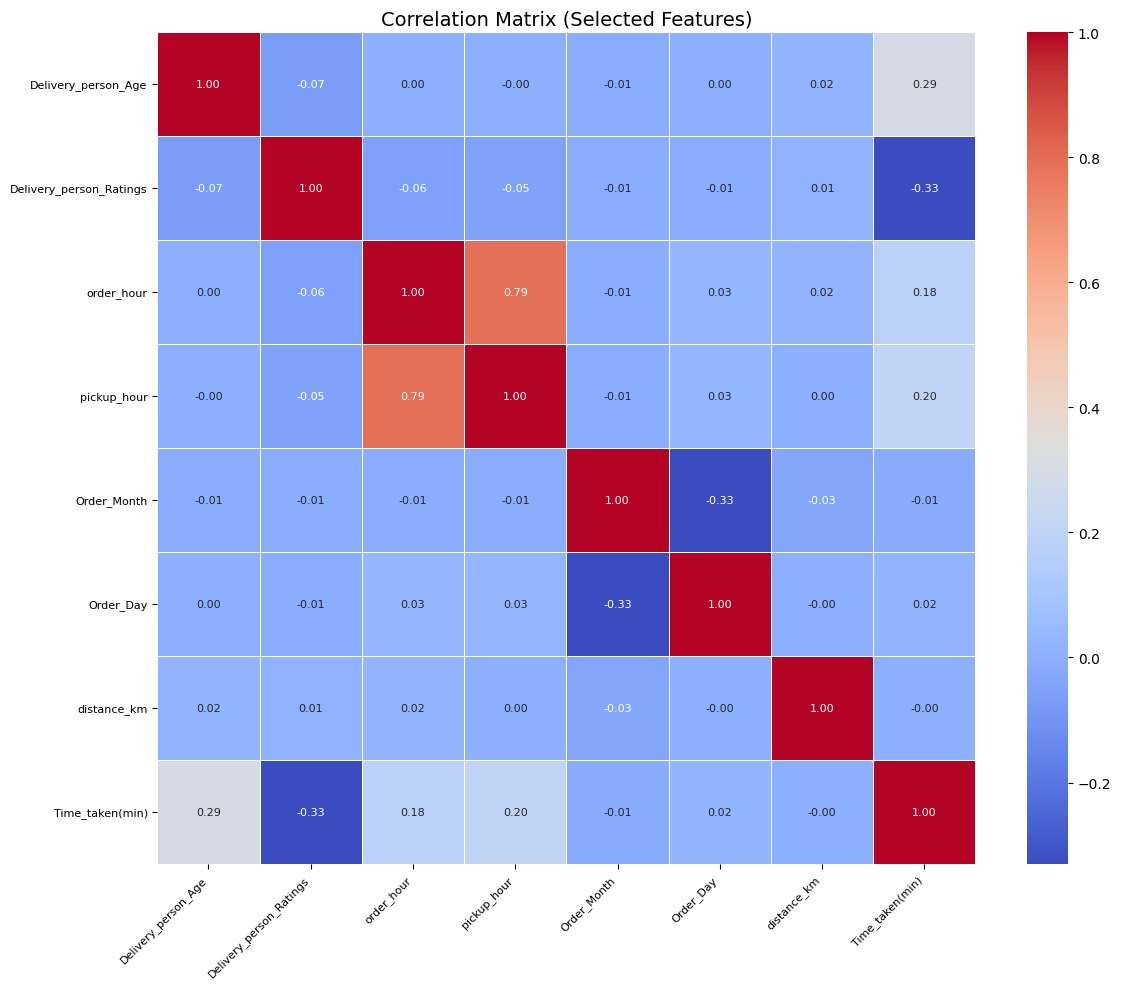

In [978]:
corr_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "order_hour",
    "pickup_hour",
    "Order_Month",
    "Order_Day",
    "distance_km",
    "Time_taken(min)"
]

plot_correlation_matrix(
    df_train_processed,
    columns=corr_cols,
    title="Correlation Matrix (Selected Features)"
)

## Séparation des données (Train / Test)

Les données sont divisées en deux ensembles afin d’évaluer correctement les performances du modèle :

- **Jeu d’entraînement (train)** : utilisé pour apprendre le modèle
- **Jeu de test (test)** : utilisé pour évaluer sa capacité de généralisation

La séparation est effectuée de manière aléatoire avec les paramètres suivants :

- **80 % des données** pour l’entraînement
- **20 % des données** pour le test
- **random_state = 42** pour garantir la reproductibilité

---

### Dimensions des datasets

- **X_train** : 36 474 lignes, 22 variables
- **X_test** : 9 119 lignes, 22 variables

---

### Objectif

Cette séparation permet :

- D’éviter le surapprentissage (*overfitting*)
- D’évaluer le modèle sur des données jamais vues
- D’obtenir une estimation fiable des performances réelles

---

### Remarque

La variable cible (*Time_taken(min)*) est séparée des variables explicatives avant le split, afin de respecter les bonnes pratiques en machine learning.

In [979]:
from sklearn.model_selection import train_test_split

X = df_train_processed.drop(columns=[target_col])
y = df_train_processed[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(36474, 23) (9119, 23)


## Construction du pipeline de régression

Afin de structurer le processus de modélisation, un pipeline complet est mis en place.
Ce pipeline permet de combiner le prétraitement des données et l’apprentissage du modèle en une seule étape cohérente et reproductible.

---

### Objectif

- Standardiser le traitement des variables
- Éviter les fuites de données (*data leakage*)
- Faciliter la comparaison entre plusieurs modèles
- Automatiser l’évaluation des performances

---

### Structure du pipeline

Le pipeline est composé de deux parties principales :

1. **Préprocessing (ColumnTransformer)**
2. **Modèle de régression**

---

### 1. Traitement des variables numériques

Les variables numériques suivent les étapes suivantes :

- Imputation des valeurs manquantes avec la médiane
- Standardisation des données (centrage et réduction)

Cela permet de rendre les variables comparables et d’améliorer les performances des modèles sensibles à l’échelle.

---

### 2. Traitement des variables catégorielles nominales

Les variables nominales sont traitées avec :

- Imputation par la valeur la plus fréquente
- Encodage One-Hot

Ce type d’encodage évite d’introduire un ordre artificiel entre les catégories.

---

### 3. Traitement des variables catégorielles ordinales

Les variables ordinales sont encodées en respectant leur ordre naturel :

- Imputation par la valeur la plus fréquente
- Encodage ordinal basé sur un ordre défini

Cela permet de conserver l’information de hiérarchie entre les catégories (ex : trafic faible → élevé).

---

### 4. Combinaison des transformations

Toutes les transformations sont regroupées via un **ColumnTransformer**, permettant :

- D’appliquer un traitement spécifique à chaque type de variable
- De centraliser le preprocessing dans un seul objet

---

### 5. Modèle de régression

Le modèle est intégré directement dans le pipeline, ce qui permet :

- D’entraîner le modèle après transformation des données
- De garantir que les mêmes transformations sont appliquées en phase de test

Le modèle est paramétrable, ce qui permet de tester plusieurs algorithmes (ex : Linear Regression, Random Forest).

---

### 6. Entraînement et prédiction

Le pipeline est entraîné sur le jeu d’entraînement, puis utilisé pour prédire sur le jeu de test.

Le temps d’entraînement est également mesuré afin de comparer les performances computationnelles des modèles.

---

### 7. Évaluation des performances

Plusieurs métriques sont utilisées :

- **MAE (Mean Absolute Error)** : erreur moyenne absolue
- **RMSE (Root Mean Squared Error)** : pénalise davantage les grandes erreurs
- **R² (coefficient de détermination)** : proportion de variance expliquée

Une validation croisée (cross-validation) est également réalisée :

- **CV RMSE** : estimation robuste de la performance du modèle

---

Ce pipeline permet :

- Une gestion rigoureuse des données
- Une évaluation fiable des modèles
- Une comparaison simple entre différentes approches

Il constitue une base solide pour tester et sélectionner le meilleur modèle de régression.

In [980]:
def build_pipeline_regression(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_nominal_cols,
    cat_ordinal_cols,
    ordinal_categories,
    model_class,
    model_name="Model",
    model_params=None
):
    import time
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.model_selection import cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
    from sklearn.impute import SimpleImputer

    if model_params is None:
        model_params = {}

    # =========================
    # NUMERICAL PIPELINE
    # =========================
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # =========================
    # NOMINAL PIPELINE
    # =========================
    cat_nominal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    # =========================
    # ORDINAL PIPELINE
    # =========================
    cat_ordinal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(categories=ordinal_categories))
    ])

    # =========================
    # COLUMN TRANSFORMER
    # =========================
    transformers = []

    if num_cols:
        transformers.append(("num", num_pipe, num_cols))

    if cat_nominal_cols:
        transformers.append(("cat_nominal", cat_nominal_pipe, cat_nominal_cols))

    if cat_ordinal_cols:
        transformers.append(("cat_ordinal", cat_ordinal_pipe, cat_ordinal_cols))

    preprocessor = ColumnTransformer(transformers)

    model = Pipeline([
        ("prep", preprocessor),
        ("model", model_class(**model_params))
    ])

    # =========================
    # TRAIN
    # =========================
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    # =========================
    # METRICS
    # =========================
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    cv_rmse = np.sqrt(-cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    ).mean())

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print("MAE :", round(mae, 2))
    print("RMSE :", round(rmse, 2))
    print("R2 :", round(r2, 4))
    print("CV RMSE :", round(cv_rmse, 2))

    return {
        "name": model_name,
        "model": model,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "cv_rmse": cv_rmse,
        "train_time": train_time
    }

## Comparaison des modèles de régression

Deux modèles ont été évalués afin de prédire le temps de livraison :

- **Linear Regression** (modèle de base)
- **Random Forest Regressor** (modèle non linéaire)

---

### Résultats

| Modèle             | MAE  | RMSE | R²     | CV RMSE |
|--------------------|------|------|--------|--------|
| Linear Regression  | 5.05 | 6.38 | 0.5364 | 6.38   |
| Random Forest      | 3.57 | 4.54 | 0.7648 | 4.55   |

---

### Analyse des performances

#### Linear Regression

- Performances moyennes
- R² ≈ 0.54 → explique environ 54 % de la variance
- Erreurs relativement élevées (RMSE = 6.38)

👉 Indique que les relations dans les données ne sont pas purement linéaires

---

#### Random Forest

- Amélioration significative des performances
- R² ≈ 0.76 → capture beaucoup mieux la variance
- Réduction importante des erreurs (RMSE = 4.54 vs 6.38)
- Résultats stables (CV RMSE ≈ RMSE test)

👉 Le modèle capture efficacement les interactions entre variables

---

### Comparaison directe

- **Réduction du RMSE** : ~29 %
- **Réduction du MAE** : ~29 %
- **Gain en R²** : +0.23


---

Ces résultats confirment que :

- Le problème est **non linéaire**
- Les interactions entre variables (temps, trafic, distance, livreur) sont importantes
- Les modèles basés sur les arbres sont mieux adaptés

---


Le modèle **Random Forest** est retenu comme meilleur modèle car :

- Il offre de meilleures performances sur toutes les métriques
- Il généralise correctement (cross-validation cohérente)
- Il est robuste face au bruit et aux relations complexes

---

### Insight clé

Le temps de livraison ne dépend pas d’une relation simple entre variables, mais d’interactions complexes, ce qui rend les modèles non linéaires indispensables pour obtenir de bonnes performances.

In [981]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
results = []

results.append(build_pipeline_regression(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_nominal_cols,
    cat_ordinal_cols,
    ordinal_categories,
    LinearRegression,
    "Linear Regression"
))

results.append(build_pipeline_regression(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_nominal_cols,
    cat_ordinal_cols,
    ordinal_categories,
    RandomForestRegressor,
    "Random Forest",
    model_params={
        "n_estimators": 200,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1
    }
))


Linear Regression
MAE : 5.03
RMSE : 6.35
R2 : 0.5394
CV RMSE : 6.36

Random Forest
MAE : 3.57
RMSE : 4.54
R2 : 0.7649
CV RMSE : 4.55


In [983]:
# =========================
# 1. RECUPERATION DU MODELE EXISTANT
# =========================

def get_trained_model(results):
    """
    Récupère automatiquement le modèle depuis results
    compatible avec différentes structures possibles
    """
    for res in results:
        if isinstance(res, dict):
            for key in ["model", "pipeline", "estimator"]:
                if key in res:
                    return res[key]
    raise ValueError("Aucun modèle trouvé dans results")

model = get_trained_model(results)

print("Model chargé :", type(model))


# =========================
# 2. SIMULATION INTERACTIVE
# =========================

import ipywidgets as widgets
from IPython.display import display, clear_output

# Widgets
age = widgets.IntSlider(value=30, min=18, max=60, description="Age")
rating = widgets.FloatSlider(value=4.7, min=1, max=5, step=0.1, description="Rating")

traffic = widgets.Dropdown(
    options=["Low", "Medium", "High", "Jam"],
    value="High",
    description="Traffic"
)

weather = widgets.Dropdown(
    options=["Sunny", "Cloudy", "Fog", "Stormy"],
    value="Sunny",
    description="Weather"
)

orders = widgets.IntSlider(value=1, min=0, max=5, description="Orders")
hour = widgets.IntSlider(value=13, min=0, max=23, description="Hour")

city = widgets.Dropdown(
    options=["Urban", "Semi-Urban", "Metropolitan"],
    value="Urban",
    description="City"
)

output = widgets.Output()


# =========================
# 3. PREDICTION
# =========================

def predict_visual(change=None):
    with output:
        clear_output()

        sample = pd.DataFrame([{
            "Delivery_person_Age": age.value,
            "Delivery_person_Ratings": rating.value,
            "Weatherconditions": weather.value,
            "Road_traffic_density": traffic.value,
            "Vehicle_condition": 2,
            "Type_of_order": "Snack",
            "Type_of_vehicle": "motorcycle",
            "multiple_deliveries": orders.value,
            "Festival": "No",
            "City": city.value,

            "Restaurant_latitude": 12.9716,
            "Restaurant_longitude": 77.5946,
            "Delivery_location_latitude": 12.9352,
            "Delivery_location_longitude": 77.6245,

            "Order_Date": "15-03-2024",
            "Time_Orderd": f"{hour.value}:00",
            "Time_Order_picked": f"{hour.value+1}:00"
        }])

        X_sim = preprocess_features(sample)

        pred = model.predict(X_sim)[0]

        print("Temps estimé :", round(pred, 2), "minutes")


# =========================
# 4. BIND
# =========================

for w in [age, rating, traffic, weather, orders, hour, city]:
    w.observe(predict_visual, names="value")

# =========================
# 5. DISPLAY
# =========================

display(age, rating, traffic, weather, orders, hour, city)
display(output)

predict_visual()

Model chargé : <class 'sklearn.pipeline.Pipeline'>


IntSlider(value=30, description='Age', max=60, min=18)

FloatSlider(value=4.7, description='Rating', max=5.0, min=1.0)

Dropdown(description='Traffic', index=2, options=('Low', 'Medium', 'High', 'Jam'), value='High')

Dropdown(description='Weather', options=('Sunny', 'Cloudy', 'Fog', 'Stormy'), value='Sunny')

IntSlider(value=1, description='Orders', max=5)

IntSlider(value=13, description='Hour', max=23)

Dropdown(description='City', options=('Urban', 'Semi-Urban', 'Metropolitan'), value='Urban')

Output()